# Clustering Analysis
Perform K-Means and Hierarchical clustering on the preprocessed customer data.

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.decomposition import PCA
from scipy.cluster.hierarchy import dendrogram, linkage

# Configuration
INPUT_FILE = 'processed_customer_data.csv'
RANDOM_STATE = 42

# Set plot style
sns.set(style="whitegrid")

## 1. Load Data

In [8]:
df = pd.read_csv(INPUT_FILE)
print(f"Data loaded. Shape: {df.shape}")
df.head()

Data loaded. Shape: (16805, 13)


,customer_id,number_complaints,distinct_stores_visited,typical_hour,percentage_of_products_bought_promotion,Age,Tenure,Total_Spend,Total_Minors,Share_Fresh_Food,Share_Groceries,Share_Tech_Gaming,Share_Drinks
0,11259,0.5,1.0,0.375,0.709009,0.741935,1.875,-0.521056,0.000000,0.859141,-1.045694,0.068080,1.637000
1,6538,1.0,1.0,-0.125,0.488764,0.129032,-0.250,-0.478577,0.333333,2.052409,-1.722193,-0.167945,2.637390
2,14274,0.0,-1.0,-0.375,-0.474370,-0.483871,0.125,0.090442,-0.666667,-0.283290,0.199068,0.640011,-0.433602
3,7796,0.0,1.0,0.000,0.047125,-0.903226,-1.125,-0.408732,-0.333333,1.449476,-0.936270,0.771541,-0.263999
4,4521,0.5,1.0,-0.625,0.076668,0.451613,1.375,0.915016,0.666667,0.459241,0.115666,-0.102444,-0.510902


## 2. K-Means Clustering

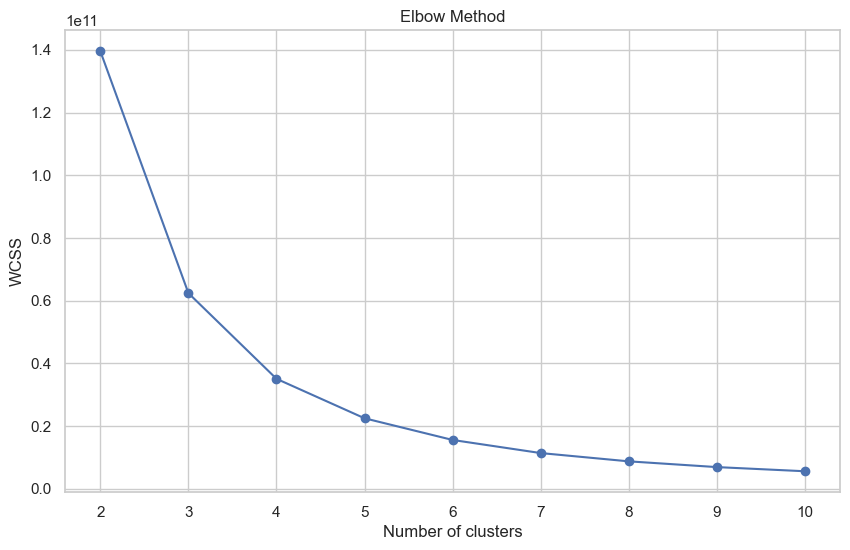

In [9]:
# 2.1 Determine optimal K using Elbow Method
wcss = []
range_k = range(2, 11)

for k in range_k:
    kmeans = KMeans(n_clusters=k, init='k-means++', random_state=RANDOM_STATE)
    kmeans.fit(df)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(10, 6))
plt.plot(range_k, wcss, marker='o')
plt.title('Elbow Method')
plt.xlabel('Number of clusters')
plt.ylabel('WCSS')
plt.show()

In [10]:
# 2.2 Fit K-Means with chosen K
# Based on typical results for this dataset, we'll start with K=4, but this should be adjusted based on the Elbow plot.
OPTIMAL_K = 4

kmeans = KMeans(n_clusters=OPTIMAL_K, init='k-means++', random_state=RANDOM_STATE)
df['kmeans_cluster'] = kmeans.fit_predict(df)

print(f"K-Means clustering completed with K={OPTIMAL_K}")

K-Means clustering completed with K=4


## 3. Hierarchical Clustering

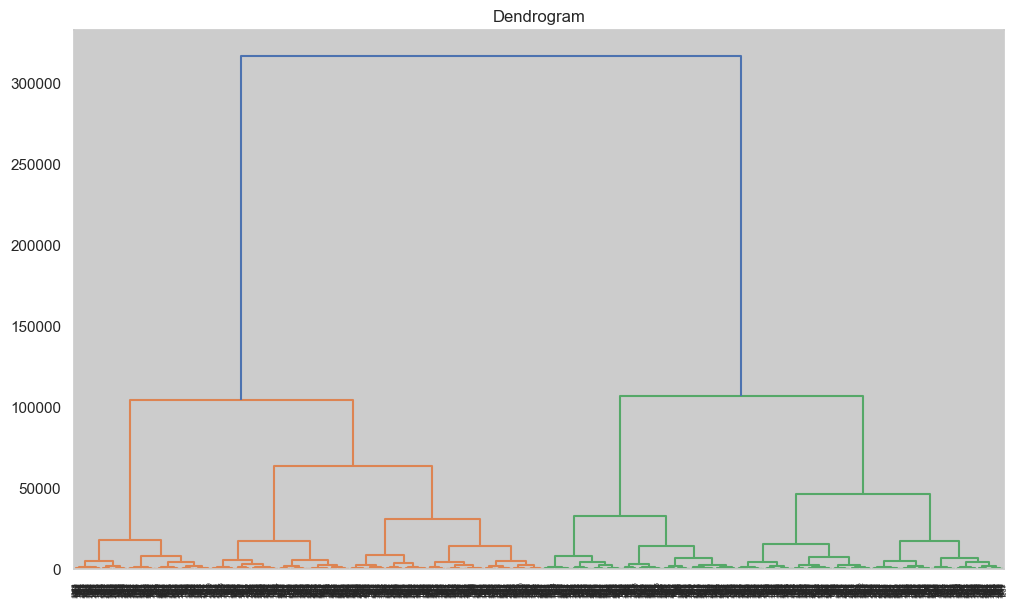

In [11]:
# 3.1 Plot Dendrogram
# We'll use a sample to keep it readable and fast if the dataset is large
sample_df = df.sample(n=min(2000, len(df)), random_state=RANDOM_STATE).drop(columns=['kmeans_cluster'], errors='ignore')

plt.figure(figsize=(12, 7))
plt.title("Dendrogram")
dend = dendrogram(linkage(sample_df, method='ward'))
plt.show()

In [12]:
# 3.2 Fit Agglomerative Clustering
# Using the same K as K-Means for comparison, or adjust based on Dendrogram
hc = AgglomerativeClustering(n_clusters=OPTIMAL_K, linkage='ward')
df['hierarchical_cluster'] = hc.fit_predict(df.drop(columns=['kmeans_cluster'], errors='ignore'))

print(f"Hierarchical clustering completed with K={OPTIMAL_K}")

Hierarchical clustering completed with K=4


## 4. Visualization (PCA)

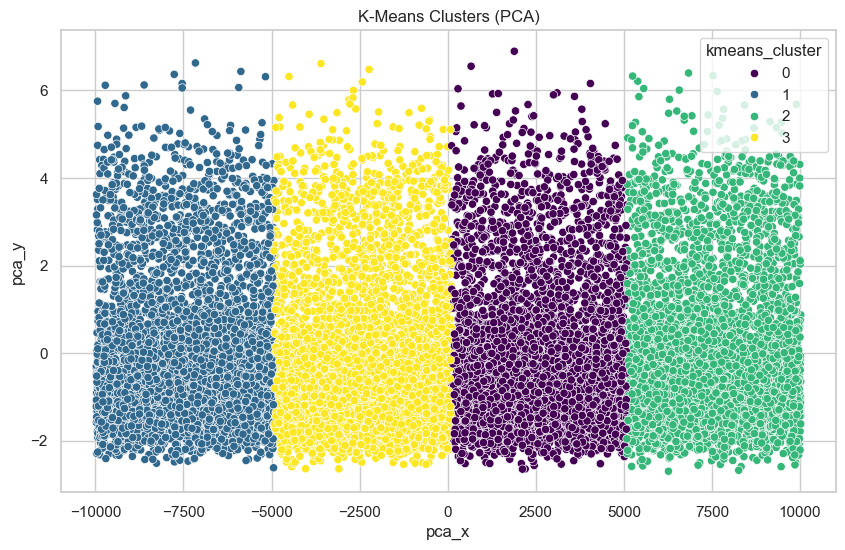

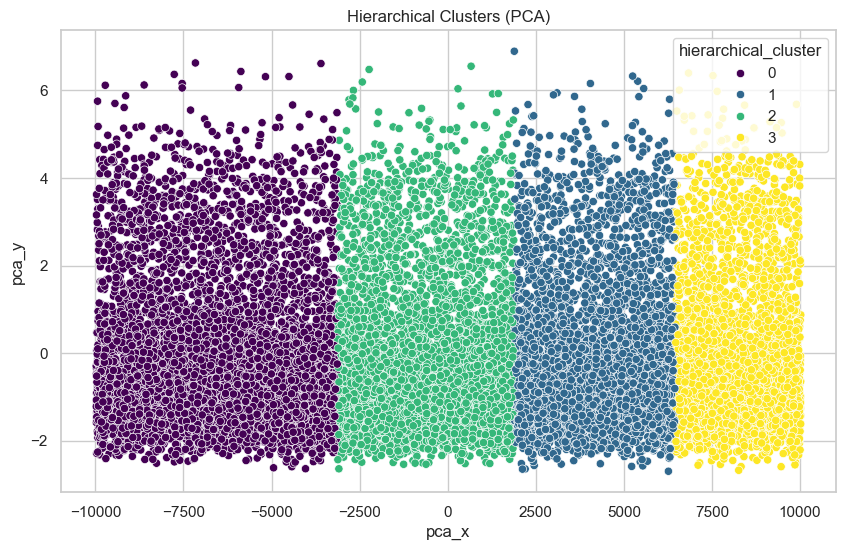

In [13]:
# Reduce to 2 dimensions for visualization
cols_for_pca = df.drop(columns=['kmeans_cluster', 'hierarchical_cluster'], errors='ignore').columns
pca = PCA(n_components=2)
pca_components = pca.fit_transform(df[cols_for_pca])

df['pca_x'] = pca_components[:, 0]
df['pca_y'] = pca_components[:, 1]

# Plot K-Means Clusters
plt.figure(figsize=(10, 6))
sns.scatterplot(x='pca_x', y='pca_y', hue='kmeans_cluster', data=df, palette='viridis')
plt.title('K-Means Clusters (PCA)')
plt.show()

# Plot Hierarchical Clusters
plt.figure(figsize=(10, 6))
sns.scatterplot(x='pca_x', y='pca_y', hue='hierarchical_cluster', data=df, palette='viridis')
plt.title('Hierarchical Clusters (PCA)')
plt.show()